<a href="https://colab.research.google.com/github/Lucaschewitch/Machine-Learning/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%D0%93%D0%B5%D0%BE%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D1%8D%D0%BA%D0%BE%D0%BB%D0%BE%D0%B3%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D1%85_%D1%84%D0%B0%D0%BA%D1%82%D0%BE%D1%80%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа. Геоанализ экологических факторов городской среды с применением методов пространственной кластеризации**




















## **Цель работы**



Освоение методов пространственного анализа и машинного обучения для оценки экологической обстановки городской территории с использованием гексагональной сетки H3, с последующим применением различных алгоритмов кластеризации и классификации.

## **Задачи**



1. Освоить инструменты загрузки и агрегации экологических геоданных с использованием API OpenStreetMap
2. Реализовать анализ пространственного распределения экологических факторов с помощью гексагональной сетки H3
3. Применить и сравнить различные алгоритмы кластеризации для выявления однородных экологических зон
4. Обучить модели классификации для прогнозирования экологического состояния новых территорий

## **Теоретическая часть**



Современный геоэкологический анализ требует комплексного подхода к обработке пространственно-распределенных данных. Применение методов машинного обучения, в частности алгоритмов кластеризации (K-means, агломеративной, спектральной, DBSCAN, HDBSCAN), позволяет выявлять неявные закономерности в распределении экологических факторов городской среды и определять территории со схожими экологическими характеристиками.

## **Этапы работы**



### **1. Определение области исследования и подготовка данных**


- Выберите городскую территорию для анализа экологической обстановки
- Используя API OpenStreetMap, загрузите данные следующих категорий:
  - Источники загрязнения (промышленные предприятия, мусоропереработка, ТЭЦ)
  - Зеленые насаждения (парки, скверы, лесопарковые зоны)
  - Водные объекты (реки, водоемы)
  - Автомагистрали (категории дорог с интенсивным движением)
  - Административные районы города

In [1]:
# Ваш код
!pip install scikit-learn geopandas h3pandas h3~=3.0 leafmap mapclassify matplotlib osmnx pyrosm kneed hdbscan joblib seaborn plotly -q

In [2]:
!apt-get install -y osmium-tool

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libboost-program-options1.74.0
The following NEW packages will be installed:
  libboost-program-options1.74.0 osmium-tool
0 upgraded, 2 newly installed, 0 to remove and 3 not upgraded.
Need to get 882 kB of archives.
After this operation, 3,863 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libboost-program-options1.74.0 amd64 1.74.0-14ubuntu3 [311 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 osmium-tool amd64 1.14.0-1 [571 kB]
Fetched 882 kB in 0s (4,814 kB/s)
Selecting previously unselected package libboost-program-options1.74.0:amd64.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../libboost-program-options1.74.0_1.74.0-14ubuntu3_amd64.deb ...
Unpacking libboost-program-options1.74.0:amd64 (1.74.0-14ubuntu3) ...
Selec

In [3]:
!osmium extract -b 37.80,55.82,38.20,56.10 /content/central-fed-district-260607.osm.pbf -o /content/shchyolkovo.osm.pbf

[======================================================================] 100% 
PBF error: unexpected EOF


In [35]:
import geopandas as gpd
import pandas as pd
import numpy as np
import h3
import leafmap
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from shapely.geometry import box, Polygon
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, DBSCAN
import hdbscan
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from kneed import KneeLocator
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import joblib
import warnings
import pyrosm
warnings.filterwarnings('ignore')

In [8]:
import pyrosm

bbox = [20.40, 54.60, 20.65, 54.78]

osm = pyrosm.OSM("/content/kaliningrad-260607.osm.pbf", bounding_box=bbox)

In [14]:
poll = osm.get_pois(custom_filter={
    'landuse': ['industrial', 'landfill'],
    'power': ['plant'],
    'man_made': ['works']
})

green = osm.get_landuse(custom_filter={
    'leisure': ['park', 'garden'],
    'natural': ['wood'],
    'landuse': ['forest']
})

water = osm.get_data_by_custom_criteria(
    custom_filter={'waterway': ['river']},
    filter_type='keep',
    keep_nodes=False,
    keep_ways=True,
    keep_relations=False
)

road = osm.get_network(network_type='driving')

In [36]:
crs_proj = "EPSG:4326"

data = {}
data['poll'] = poll if poll is not None and not poll.empty else gpd.GeoDataFrame(columns=['geometry'])
data['green'] = green if green is not None and not green.empty else gpd.GeoDataFrame(columns=['geometry'])
data['water'] = water if water is not None and not water.empty else gpd.GeoDataFrame(columns=['geometry'])
data['road'] = road if road is not None and not road.empty else gpd.GeoDataFrame(columns=['geometry'])

for k in data:
    if not data[k].empty:
        data[k] = data[k].to_crs(crs_proj)
    else:
        data[k] = gpd.GeoDataFrame(columns=['geometry'], crs=crs_proj)

In [37]:
for k in data:
    print(k, len(data[k]))

poll 576
green 538
water 38
road 17978


### **2. Агрегация данных с использованием гексагональной сетки H3**


- Сгенерируйте гексагональную сетку H3 оптимального разрешения для выбранной территории
- Для каждой ячейки H3 рассчитайте:
  - Количество и плотность источников загрязнения в радиусе 1600м
  - Площадь и процент покрытия зелеными насаждениями в радиусе 800м
  - Протяженность водных объектов в радиусе 1600м
  - Плотность автомагистралей в радиусе 1600м
- Выполните нормализацию полученных показателей
- Сформируйте интегральный индекс экологического благополучия территории


In [38]:
# Ваш код
def calc_cell(geom):
    b1600 = geom.buffer(1600)
    b800 = geom.buffer(800)
    n_poll = data['poll'].geometry.intersects(b1600).sum()
    len_water = data['water'].geometry.intersection(b1600).length.sum()
    len_road = data['road'].geometry.intersection(b1600).length.sum()
    area_green = data['green'].geometry.intersection(b800).area.sum()
    return n_poll, len_water, len_road, area_green

In [39]:
bbox_poly = box(*bbox)
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_poly], crs="EPSG:4326").to_crs(crs_proj)
res = 9
h3_idx = list(h3.polyfill(bbox_poly.__geo_interface__, res))
h3_geom = [Polygon(h3.h3_to_geo_boundary(h, geo_json=True)) for h in h3_idx]
h3_gdf = gpd.GeoDataFrame({'h3': h3_idx, 'geometry': h3_geom}, crs="EPSG:4326").to_crs(crs_proj)

In [40]:
feat = ['n_poll', 'len_water', 'len_road', 'area_green']
h3_gdf[feat] = h3_gdf.geometry.apply(lambda g: pd.Series(calc_cell(g)))

In [41]:
scaler = MinMaxScaler()
h3_gdf[feat] = scaler.fit_transform(h3_gdf[feat])
h3_gdf['score'] = h3_gdf['len_water'] + h3_gdf['area_green'] - h3_gdf['n_poll'] - h3_gdf['len_road']

In [42]:
X = h3_gdf[feat + ['score']].copy()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(6129, 5)


In [43]:
print("Статистика X_scaled:")
print(pd.DataFrame(X_scaled, columns=feat+['score']).describe())
print("\nДисперсия каждого признака:", np.var(X_scaled, axis=0))
print("Уникальных строк в X_scaled:", np.unique(X_scaled, axis=0).shape[0])
print("Сумма всех значений:", np.sum(X_scaled))

Статистика X_scaled:
       n_poll  len_water  len_road  area_green   score
count  6129.0     6129.0    6129.0      6129.0  6129.0
mean      0.0        0.0       0.0         0.0     0.0
std       0.0        0.0       0.0         0.0     0.0
min       0.0        0.0       0.0         0.0     0.0
25%       0.0        0.0       0.0         0.0     0.0
50%       0.0        0.0       0.0         0.0     0.0
75%       0.0        0.0       0.0         0.0     0.0
max       0.0        0.0       0.0         0.0     0.0

Дисперсия каждого признака: [0. 0. 0. 0. 0.]
Уникальных строк в X_scaled: 1
Сумма всех значений: 0.0


In [44]:
print("ДО нормализации:")
print(h3_gdf[feat].describe())
print("Количество ненулевых n_poll:", (h3_gdf['n_poll'] > 0).sum())
print("Количество ненулевых len_water:", (h3_gdf['len_water'] > 0).sum())
print("Количество ненулевых len_road:", (h3_gdf['len_road'] > 0).sum())
print("Количество ненулевых area_green:", (h3_gdf['area_green'] > 0).sum())

ДО нормализации:
       n_poll  len_water  len_road  area_green
count  6129.0     6129.0    6129.0      6129.0
mean      0.0        0.0       0.0         0.0
std       0.0        0.0       0.0         0.0
min       0.0        0.0       0.0         0.0
25%       0.0        0.0       0.0         0.0
50%       0.0        0.0       0.0         0.0
75%       0.0        0.0       0.0         0.0
max       0.0        0.0       0.0         0.0
Количество ненулевых n_poll: 0
Количество ненулевых len_water: 0
Количество ненулевых len_road: 0
Количество ненулевых area_green: 0


### **3. Определение оптимального числа кластеров**


- Постройте график метода локтя (Elbow method) для определения оптимального числа кластеров
- Оцените качество кластеризации с помощью внутренних метрик кластеризации
- Определите оптимальное число кластеров на основе комбинации различных метрик

In [27]:
# Ваш код
inert = []
sil = []
cal = []
dav = []
k_range = range(3, 13)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    labs = km.labels_
    uniq = len(np.unique(labs))

    inert.append(km.inertia_)

    if uniq > 1:
        sil.append(silhouette_score(X_scaled, labs))
        cal.append(calinski_harabasz_score(X_scaled, labs))
        dav.append(davies_bouldin_score(X_scaled, labs))
    else:
        sil.append(np.nan)
        cal.append(np.nan)
        dav.append(np.nan)

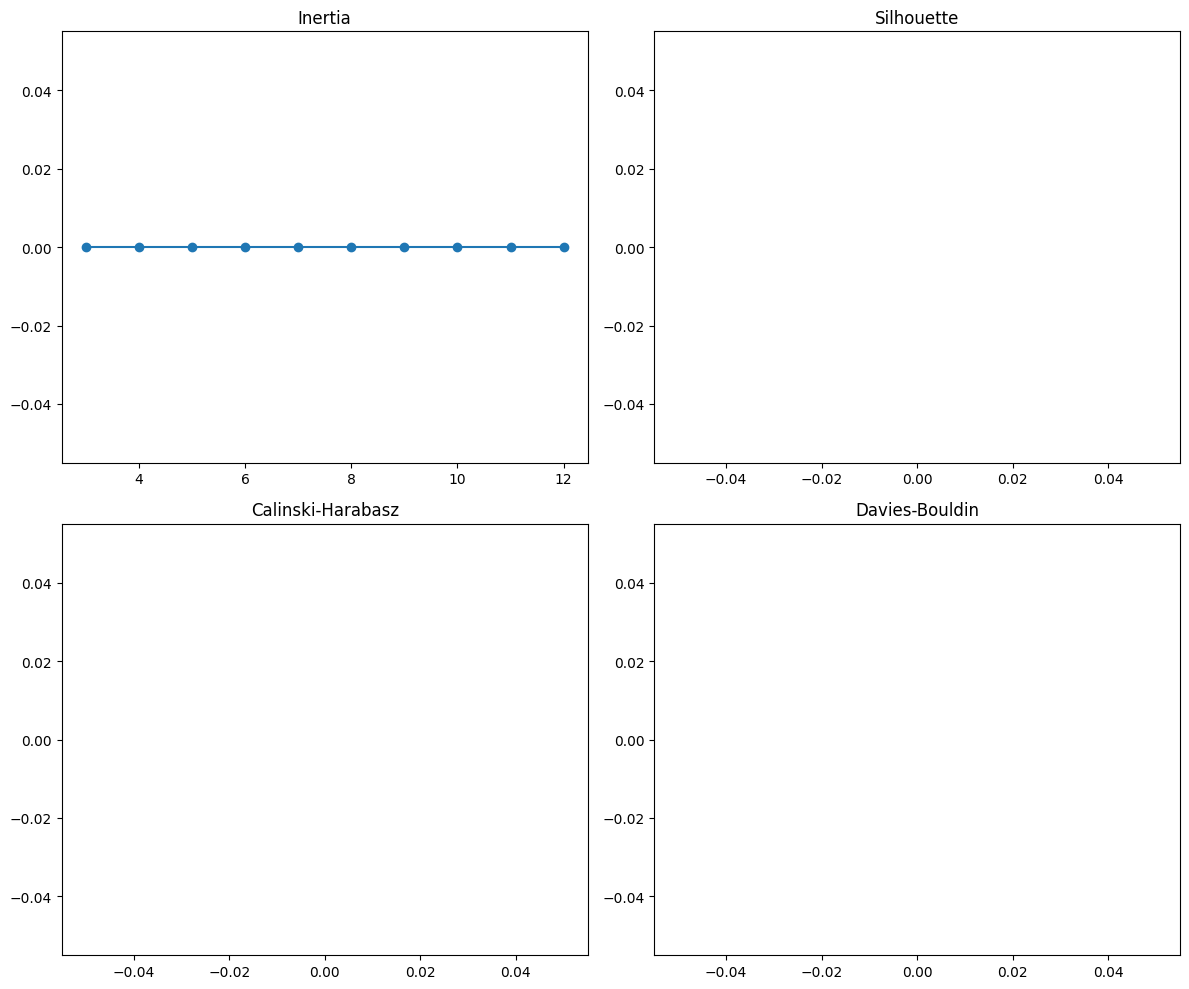

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0,0].plot(k_range, inert, 'o-')
axes[0,0].set_title('Inertia')
axes[0,1].plot(k_range, sil, 'o-')
axes[0,1].set_title('Silhouette')
axes[1,0].plot(k_range, cal, 'o-')
axes[1,0].set_title('Calinski-Harabasz')
axes[1,1].plot(k_range, dav, 'o-')
axes[1,1].set_title('Davies-Bouldin')
plt.tight_layout()
plt.show()

In [29]:
kl = KneeLocator(list(k_range), inert, curve='convex', direction='decreasing')
opt_k = kl.elbow if kl.elbow is not None else 3
print("Elbow k:", opt_k)

valid_sil = [s for s in sil if not np.isnan(s)]
if valid_sil:
    best_sil_k = k_range[sil.index(max(valid_sil))]
    print("Best Silhouette k:", best_sil_k)

Elbow k: 3


In [30]:
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_scaled)
dist, _ = nn.kneighbors(X_scaled)
dist = np.sort(dist[:,4])
kl2 = KneeLocator(range(len(dist)), dist, curve='convex', direction='increasing')
eps_opt = dist[kl2.knee] if kl2.knee else np.percentile(dist, 10)
print("eps:", eps_opt)

eps: 0.0


### **4. Сравнительный анализ алгоритмов кластеризации**


- Реализуйте и сравните следующие алгоритмы кластеризации:
  - K-means
  - Агломеративная кластеризация
  - Спектральная кластеризация
  - DBSCAN (с оптимальным значением eps)
  - HDBSCAN
- Для каждого алгоритма оцените:
  - Качество кластеризации по основным метрикам
  - Распределение точек по кластерам
  - Характерные особенности выявленных кластеров

In [ ]:
# Ваш код

### **5. Визуализация и интерпретация результатов**


- Визуализируйте результаты кластеризации на карте с использованием leafmap
- Постройте тепловые карты средних значений экологических факторов для каждого кластера
- Выполните снижение размерности с помощью PCA и визуализируйте кластеры в двумерном пространстве
- Проанализируйте профили кластеров и составьте их экологические характеристики
- Разработайте рекомендации по улучшению экологической обстановки для каждого типа территории

In [ ]:
# Ваш код

### **6. Разработка моделей классификации**


- На основе результатов лучшего алгоритма кластеризации подготовьте данные для обучения классификаторов
- Обучите и сравните различные модели классификации:
  - Логистическая регрессия
  - Дерево решений
  - Случайный лес
  - Градиентный бустинг
  - SVM
  - K-ближайших соседей
- Оцените качество моделей с использованием кросс-валидации
- Выберите оптимальную модель и сохраните её для дальнейшего использования

In [ ]:
# Ваш код

## **Требования к отчету (Структуре блокнота)**



1. Описание выбранной территории и источников данных
2. Методика расчета экологических показателей с обоснованием выбора буферных зон и весовых коэффициентов
3. Сравнительный анализ результатов кластеризации с обоснованием выбора оптимального алгоритма
4. Карты распределения экологических факторов и результатов кластеризации
5. Подробная характеристика выявленных экологических зон (кластеров) с рекомендациями по их развитию
6. Анализ эффективности разработанных моделей классификации
7. Выводы об экологическом состоянии исследуемой территории и возможностях практического применения полученных результатов